
# Bank Clients - Exploratory Data Analysis (EDA) & Outlier Detection
This notebook performs Initial Data Exploration (EDA) and Outlier Detection based on the dataset and its metadata.

**Features MetaData:**
* `ID`: Numerical ID
* `Age`: Age, in years
* `Gender`: Female = 1, Male = 0
* `Job`: 1 = Unemployed, 2 = Employee/Worker, 3 = Manager/Executive, 4 = Entrepreneur/Freelancer, 5 = Retired
* `Area`: 1 = North, 2 = Center, 3 = South/Islands
* `CitySize`: 1 = Small town, 2 = Medium-sized city, 3 = Large city (>200k population)
* `FamilySize`: Number of family members
* `Income`: Normalized Income (percentiles)
* `Wealth`: Normalized Wealth (percentiles)
* `Debt`: Normalized Debt (percentiles)
* `FinEdu`: Normalized Financial Education (percentiles)
* `ESG`: Normalized ESG propensity (percentiles)
* `Digital`: Normalized Digital propensity (percentiles)
* `BankFriend`: Normalized Bank Friendliness (percentiles)
* `LifeStyle`: Normalized Lifestyle Index (percentiles)
* `Luxury`: Normalized Luxury spending (percentiles)
* `Saving`: Normalized Saving propensity (percentiles)
* `Investments`: 1 = no investments; 2 = mostly lump sum; 3 = mostly capital accumulation

Let's begin by importing the necessary libraries.


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")



## 1. Data Loading and Sanity Checks
First, we load the dataset and perform basic sanity checks for missing values and duplicates.


In [ ]:

data_path = Path("Data") / "Dataset1_BankClients.xlsx"

# Load data
df = pd.read_excel(data_path)

print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (5000, 18)


,ID,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,1,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,2,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,3,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,4,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,5,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


In [ ]:

# Drop the ID column as it's not useful for analysis
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Check for missing values
print("Missing values in each column:\n", df.isna().sum())

# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")


Missing values in each column:
 Age            0
Gender         0
Job            0
Area           0
CitySize       0
FamilySize     0
Income         0
Wealth         0
Debt           0
FinEdu         0
ESG            0
Digital        0
BankFriend     0
LifeStyle      0
Luxury         0
Saving         0
Investments    0
dtype: int64

Number of duplicate rows: 0



## 2. Univariate Analysis (Numerical)
Let's analyze the distribution of numerical variables using histograms and boxplots. 
We'll check if the supposedly normalized variables really lie in the `[0, 1]` range, and if `Age` and `FamilySize` are reasonable.


In [ ]:

# Separate numerical and categorical columns based on metadata
categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
numerical_cols = [col for col in df.columns if col not in categorical_cols]

# Summary statistics for numerical columns
df[numerical_cols].describe()


,Age,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,60.450400,2.488400,0.575839,0.579228,0.429462,0.511014,0.587227,0.527558,0.619068,0.462401,0.474992,0.521119
std,21.822373,1.407644,0.212970,0.214550,0.223622,0.186931,0.167703,0.213837,0.162662,0.221361,0.240388,0.186297
min,19.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.043817,0.000000,0.123195,0.000000,0.000000,0.000000
25%,42.000000,1.000000,0.414879,0.415849,0.255883,0.369985,0.466663,0.367967,0.505579,0.280951,0.273419,0.396462
50%,61.000000,2.000000,0.580220,0.588866,0.445857,0.504226,0.599242,0.519185,0.625231,0.445644,0.458475,0.538723
75%,80.000000,3.000000,0.749568,0.750469,0.598060,0.654515,0.710918,0.697408,0.747023,0.635747,0.663450,0.660904
max,95.000000,6.000000,0.983000,0.995597,0.976912,0.962526,0.989520,0.971778,0.974230,0.992283,0.995914,0.965525


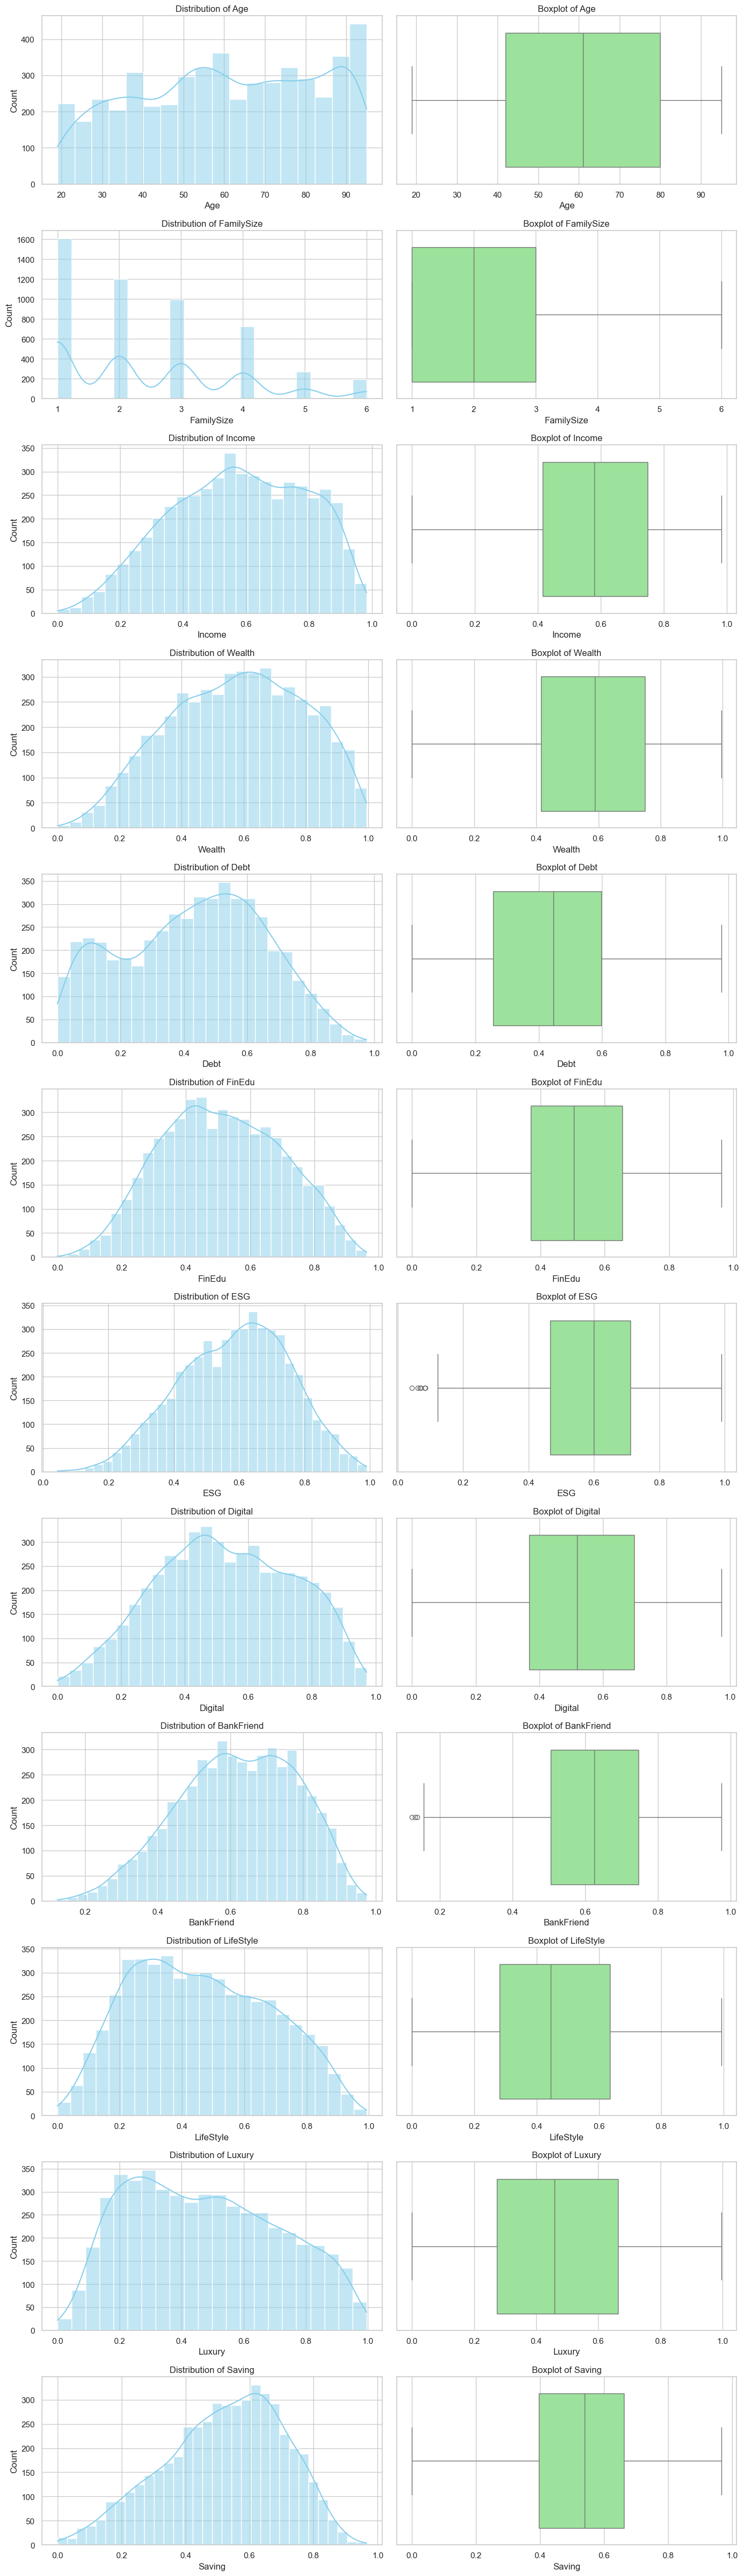

In [ ]:

# Plot Histograms and Boxplots for numerical variables
normalized_vars = [col for col in numerical_cols if col not in ['Age', 'FamilySize']]

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 4 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()



### Outlier Checks on Numerical Features
We should explicitly verify `Age` bounds and bounds for normalized `[0,1]` variables.


In [ ]:

# Check Age bounds
print(f"Age range: {df['Age'].min()} to {df['Age'].max()}")
if df['Age'].min() < 0 or df['Age'].max() > 120:
    print("Warning: Age contains unrealistic values.")

# Check FamilySize bounds
print(f"FamilySize range: {df['FamilySize'].min()} to {df['FamilySize'].max()}")

# Check normalized variables bounds
for col in normalized_vars:
    min_val, max_val = df[col].min(), df[col].max()
    if min_val < 0 or max_val > 1:
        print(f"Warning: {col} is out of [0, 1] bounds! Min: {min_val}, Max: {max_val}")


Age range: 19 to 95
FamilySize range: 1 to 6



## 3. Univariate Analysis (Categorical)
Now, let's explore categorical variables with bar charts and verify they align with the metadata encoding.


Gender unique values: [0, 1]
Job unique values: [1, 2, 3, 4, 5]
Area unique values: [1, 2, 3]
CitySize unique values: [1, 2, 3]
Investments unique values: [1, 2, 3]


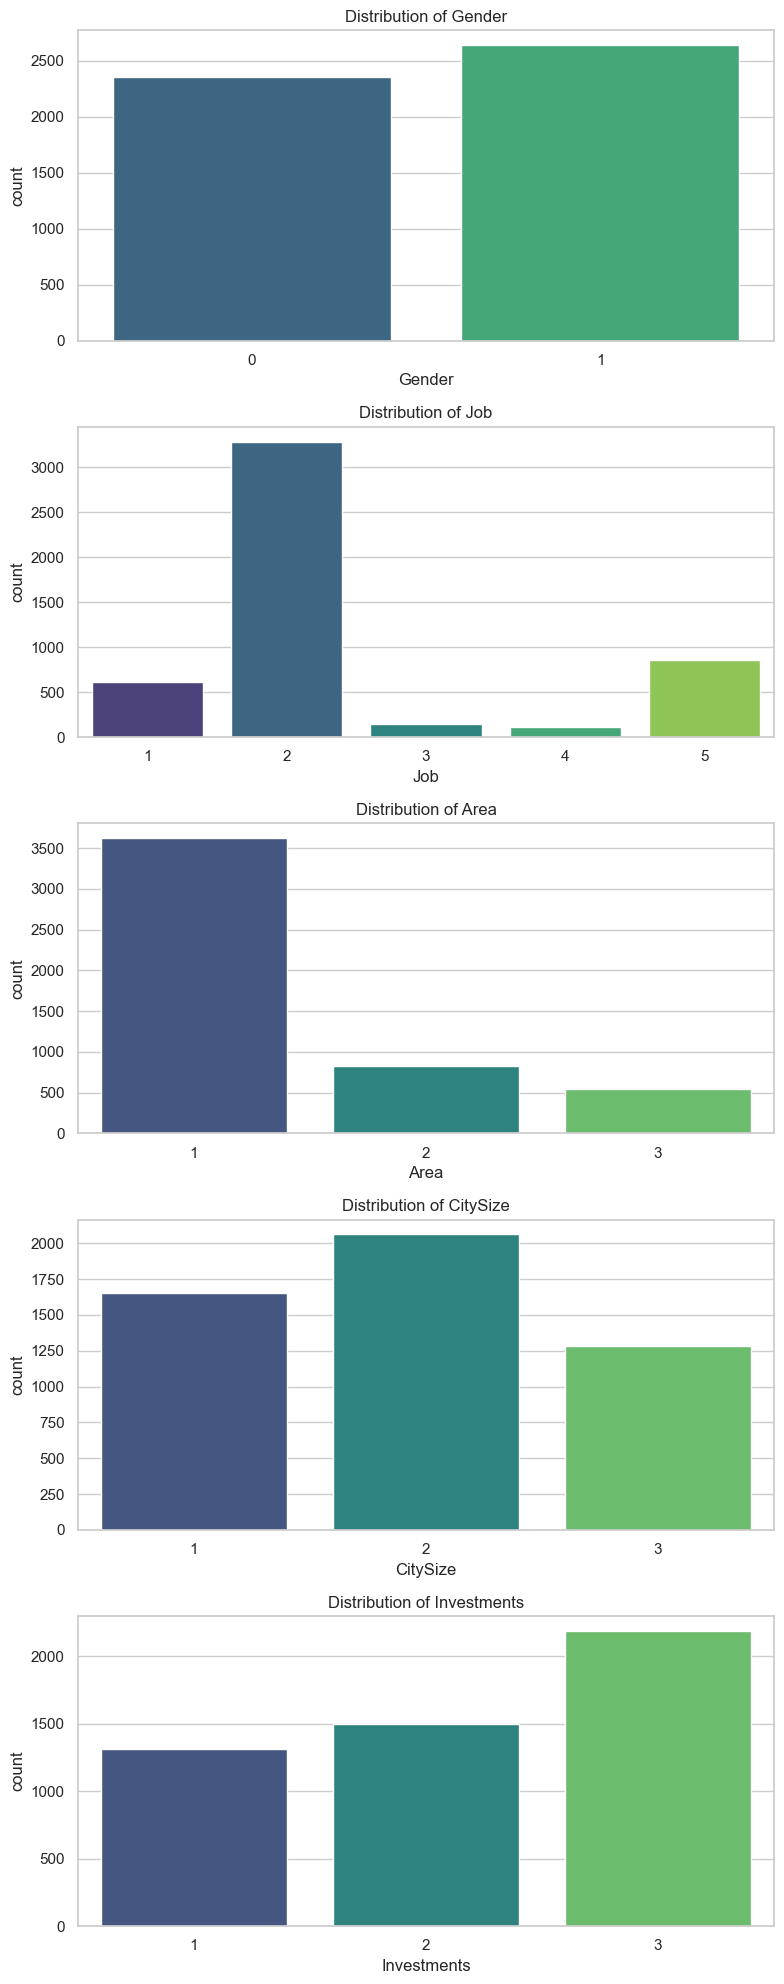

In [ ]:

# Plot count distributions for categorical features
fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(8, 4 * len(categorical_cols)))

for i, col in enumerate(categorical_cols):
    sns.countplot(x=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    
    # Check for invalid categories based on metadata
    unique_vals = sorted(df[col].dropna().unique())
    print(f"{col} unique values: {unique_vals}")

plt.tight_layout()
plt.show()



## 4. Bivariate Analysis & Correlations
Using a correlation heatmap to look for highly correlated features (Pearson's coefficient > 0.8 or < -0.8). Highly correlated features might provide duplicate information for distance-based clustering.


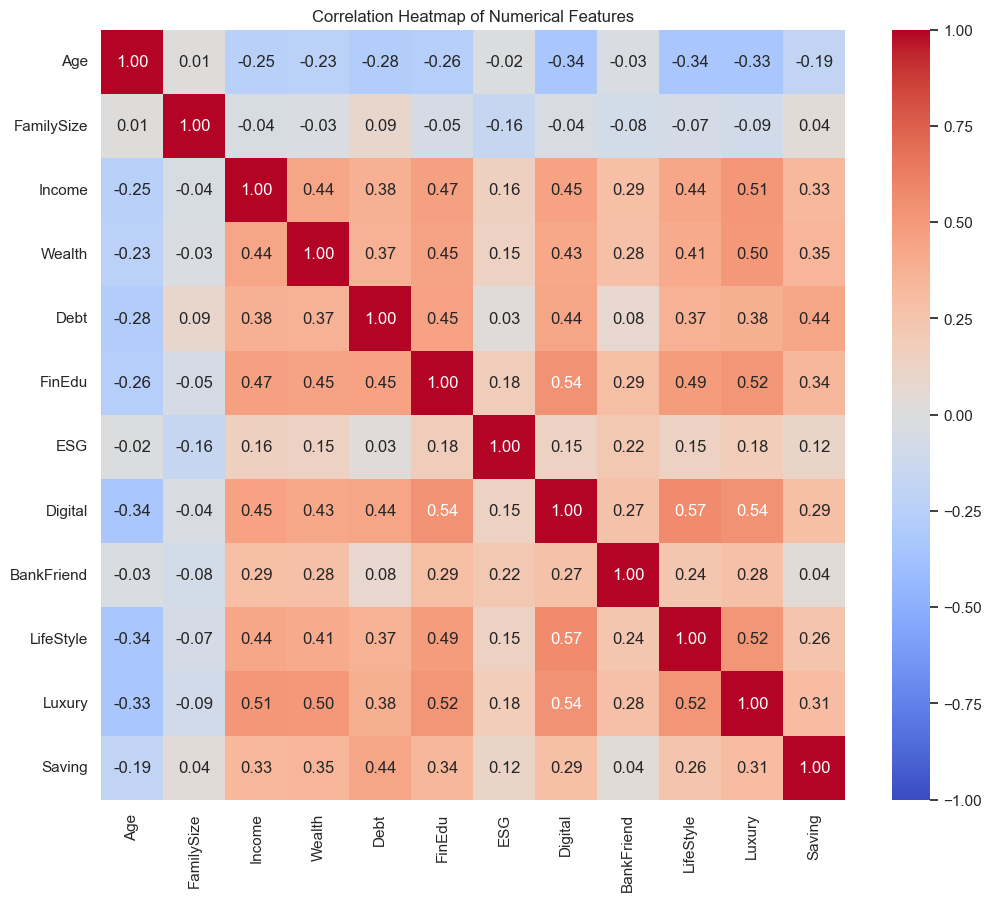

In [ ]:

# Correlation heatmap for numerical variables
plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


In [ ]:

# Identify highly correlated pairs
threshold = 0.8
highly_correlated = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            highly_correlated.append((colname_i, colname_j, corr_val))

if highly_correlated:
    print(f"Highly correlated features (|r| > {threshold}):")
    for pair in highly_correlated:
        print(f"{pair[0]} & {pair[1]}: {pair[2]:.3f}")
else:
    print(f"No highly correlated numerical features found above |r| = {threshold}.")


No highly correlated numerical features found above |r| = 0.8.



## 5. Advanced Duplicate Checks
We previously checked for perfectly identical rows. Now let's check for partial duplicates — for example, clients who have the exact same financial profile but different demographic data, which can sometimes indicate synthetic data artifacts or severe data entry errors.


In [ ]:

# Check for clients with identical financial features
financial_cols = ['Income', 'Wealth', 'Debt', 'FinEdu', 'ESG', 'Digital', 'BankFriend', 'LifeStyle', 'Luxury', 'Saving', 'Investments']
financial_dupes = df.duplicated(subset=financial_cols, keep=False)

print(f"Number of rows with identical financial profiles: {financial_dupes.sum()}")

if financial_dupes.sum() > 0:
    print("Sample of identical financial profiles:")
    display(df[financial_dupes].sort_values(by=financial_cols).head())


Number of rows with identical financial profiles: 0



## 6. Bivariate Analysis (Demographics vs Financials)
Let's see how wealth and income vary by job category using boxplots to ensure the data aligns with real-world expectations.


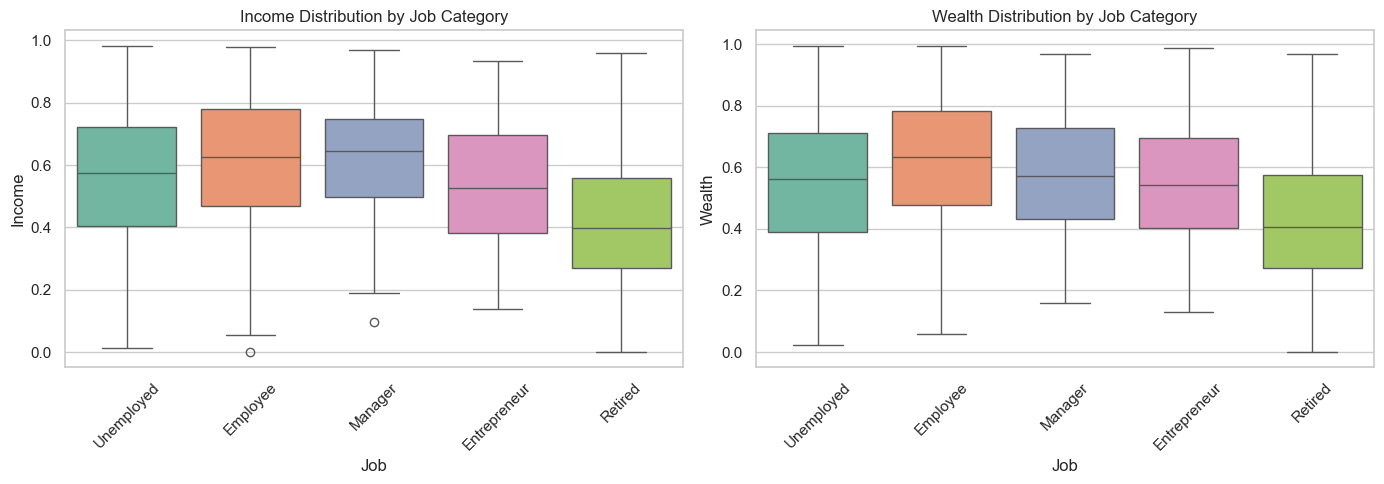

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income by Job
sns.boxplot(x='Job', y='Income', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Income Distribution by Job Category')
axes[0].set_xticklabels(['Unemployed', 'Employee', 'Manager', 'Entrepreneur', 'Retired'], rotation=45)

# Wealth by Job
sns.boxplot(x='Job', y='Wealth', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Wealth Distribution by Job Category')
axes[1].set_xticklabels(['Unemployed', 'Employee', 'Manager', 'Entrepreneur', 'Retired'], rotation=45)

plt.tight_layout()
plt.show()



## 7. Domain Knowledge Anomaly Detection
We'll manually isolate logical inconsistencies in the data based on our understanding of the features. We found a few interesting cohorts (like the "Rich Unemployed", or "Young Large Families").


In [ ]:

# 1. Very young people who are officially "Retired"
young_retirees = df[(df['Age'] < 50) & (df['Job'] == 5)]

# 2. Minors (under 18) who are employed, managers, or entrepreneurs (Assuming min age 18)
working_minors = df[(df['Age'] < 18) & (df['Job'].isin([2, 3, 4]))]

# 3. Unemployed people in the top 10% of Income
rich_unemployed = df[(df['Job'] == 1) & (df['Income'] > 0.9)]

# 4. People with NO investments but in the top 5% of Wealth
wealthy_no_investments = df[(df['Investments'] == 1) & (df['Wealth'] > 0.95)]

# 5. Very young individuals with unusually large families
young_large_families = df[(df['Age'] <= 20) & (df['FamilySize'] >= 4)]

print(f"Young Retirees (Age < 50): {len(young_retirees)}")
print(f"Working Minors (Age < 18): {len(working_minors)}")
print(f"Rich Unemployed: {len(rich_unemployed)}")
print(f"Wealthy No Investments: {len(wealthy_no_investments)}")
print(f"Young Large Families: {len(young_large_families)}")

# Depending on the modeling strategy, we may choose to DROP young_retirees and working_minors
# df = df.drop(young_retirees.index)


Young Retirees (Age < 50): 57
Working Minors (Age < 18): 0
Rich Unemployed: 28
Wealthy No Investments: 8
Young Large Families: 24



## 8. Multivariate Outlier Detection (Isolation Forest)
Instead of looking at outliers one variable at a time, what if someone is slightly unusual across *many* dimensions? We will use an Isolation Forest to find the top 1% most anomalous clients in the dataset.


In [ ]:

from sklearn.ensemble import IsolationForest

# We fit Isolation Forest on numerical features. 
# It works well even without strict scaling, but since our features are mostly [0,1], we are good.
iso_forest = IsolationForest(contamination=0.01, random_state=42) # Flag top 1% as outliers
outliers = iso_forest.fit_predict(df[numerical_cols])

# -1 means outlier, 1 means inlier
df['Is_Outlier'] = outliers

print(f"Number of multivariate outliers detected: {len(df[df['Is_Outlier'] == -1])}")

# Let's drop the outliers for the clean dataset 
#df_clean = df[df['Is_Outlier'] == 1].drop(columns=['Is_Outlier'])
#print(f"Cleaned Dataset Shape: {df_clean.shape}")


Number of multivariate outliers detected: 50
Cleaned Dataset Shape: (4950, 17)
